Парная линейная регрессия
Цель работы
    Познакомиться с моделью парной линейной регрессии регрессии и методом градиентного спуска.

Содержание работы
Найти оценки параметров модели парной линейной регрессии прямыми вычислениями и палучить с помощью модели прогнозы результативного прознака.
Найти оценки параметров модели парной линейной регрессии с использованием метода градиентного спуска.
Оценить качество построенной модели, сравнив на графике обучающую выборку и прогнозы.
Построить кривые обучения.

In [1]:
#Загрузим необходимые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Исходные данные: x - расходы на рекламу, Y - объемы продаж
x = np.array([3, 5, 7, 6, 9])
Y = np.array([3, 7, 11, 14, 15])
display(x, Y)

array([3, 5, 7, 6, 9])

array([ 3,  7, 11, 14, 15])

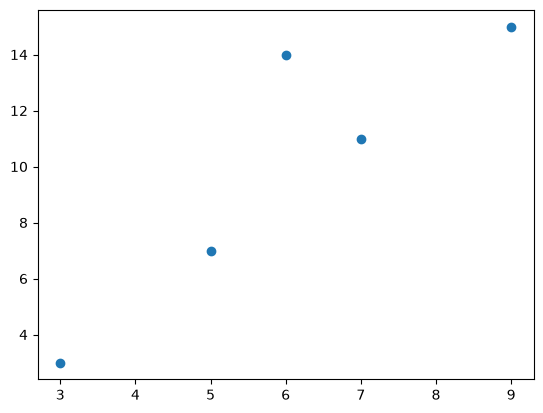

In [3]:
#Изобразим их на графике
plt.figure()
plt.scatter(x, Y)
plt.show()

In [4]:
#Вычислим оценки коэффициентов парной линейной регрессии по формулам
a1 = ((x - x.mean())*(Y - Y.mean())).mean()/((x - x.mean())**2).mean()
a0 = Y.mean() - a1*x.mean()
print("Модель линейной регрессии: Y^ = ", a0, " + ", a1, "* x")

Модель линейной регрессии: Y^ =  -2.0  +  2.0 * x


In [5]:
#Дадим серию прогнозов Y^ для x от 3 до 9 с шагом 1
x_space = np.linspace(3, 9, 7)
print(x_space)
Y_pred = a0 + a1*x_space
print(Y_pred)

[3. 4. 5. 6. 7. 8. 9.]
[ 4.  6.  8. 10. 12. 14. 16.]


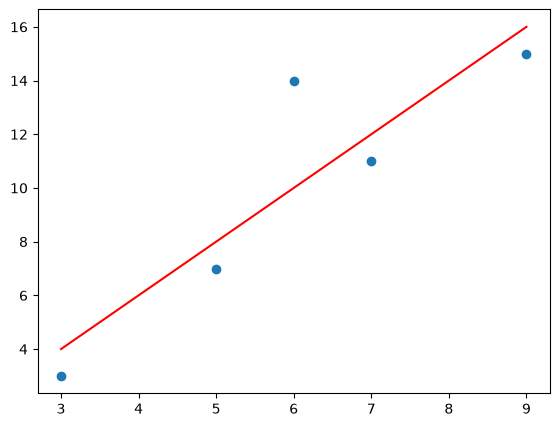

In [6]:
#Изобразим на графике исходные данные и прогнозы 
fig  = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')
#ax.scatter(x_space, Y_pred)

In [7]:
#Реализуем шаг градиентного спуска в модели парной лдинейной регрессии
class SimpleRegression(object):
    def __init__(self):
        self.a0 = 0
        self.a1 = 0
    def predict(self, x):
        return self.a0 + self.a1*x
    def MSE(self, x, Y):
        return ((self.predict(x)-Y)**2).mean()
    def fit(self, x, Y):
        alpha = 0.1
        dT_a0 = -2*sum((Y -self.predict(x)))
        dT_a1 = -2*sum((Y -self.predict(x))*x)
        self.a0 -= alpha*dT_a0
        self.a1 -= alpha*dT_a1

In [8]:
#Получим прогнозы до градиентного спуска с начальными значениями параметров
regr = SimpleRegression()
print(regr.predict(3))
print(regr.predict(5))
print(regr.predict(7))
print(regr.predict(6))
print(regr.predict(9))
print(regr.MSE(x, Y))

0
0
0
0
0
120.0


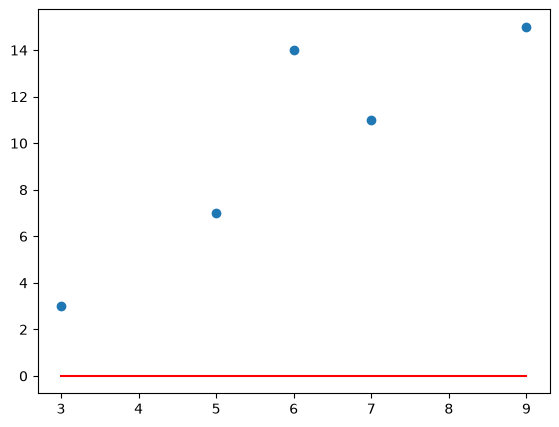

In [9]:
#Выведем прогнозы до градиентного спуска на графике
x_space = np.linspace(3, 9, 7)
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

MSE после первого шага градиентного спуска:  183892.0


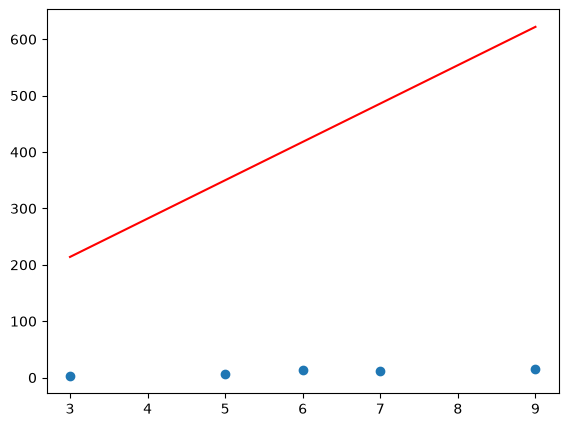

In [10]:
#Реализуем шаг градиентного спуска
regr.fit(x, Y)
print("MSE после первого шага градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

In [11]:
#Реализуем цикл градиентного спуска
class SimpleRegression(object):
    def __init__(self):
        self.a0 = 0
        self.a1 = 0
    def predict(self, x):
        return self.a0 + self.a1*x
    def MSE(self, x, Y):
        return ((Y - self.predict(x))**2).mean()
    def MAE(self, x, Y):
        return abs(Y - self.predict(x)).mean()
    def MAPE(self, x, Y):
        return abs((Y - self.predict(x))/Y).mean()
    def fit(self, x, Y, alpha = 0.001, epsylon = 0.01, max_steps = 5000):
        steps, errors = [], []
        step = 0
        for _ in range(max_steps):
            dT_a0 = -2*sum((Y -self.predict(x)))
            dT_a1 = -2*sum((Y -self.predict(x))*x)
            self.a0 -= alpha*dT_a0
            self.a1 -= alpha*dT_a1
            new_error = self.MSE(x, Y)
            step += 1
            steps.append(step)
            errors.append(new_error)
            if new_error < epsylon:
                break
        return steps, errors

In [12]:
#Запустим цикл градиентного спуска с заданной точностью 5
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.001, epsylon = 5)

5.004697916218
8.190462542210001
11.376227168202002
9.783344855206002
14.561991794194002
MSE после градиентного спуска:  4.709918696051655


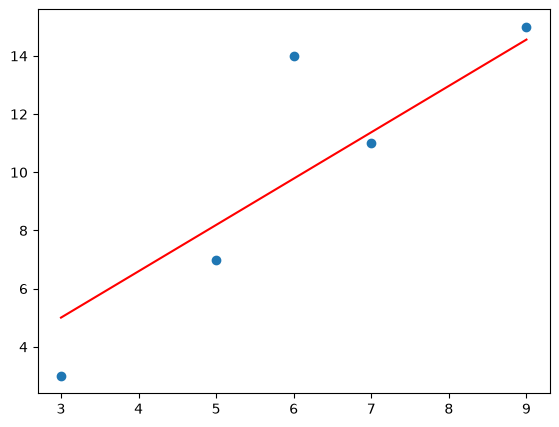

In [13]:
#Выведем график  прогнозов и вычислим MSE
print(regr.predict(3))
print(regr.predict(5))
print(regr.predict(7))
print(regr.predict(6))
print(regr.predict(9))
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

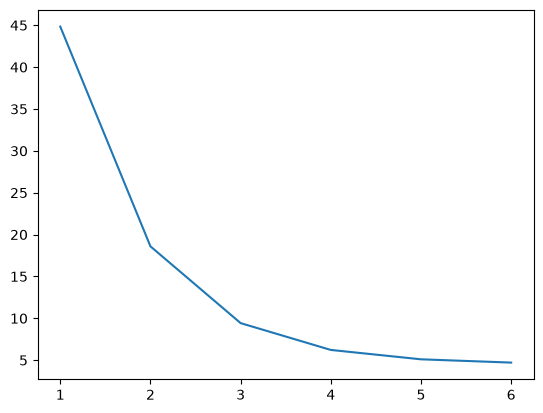

In [14]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)

In [15]:
#Запустим цикл градиентного спуска с заданной точностью 0.05
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.001, epsylon = 0.05)

MSE после градиентного спуска:  4.000028517306817


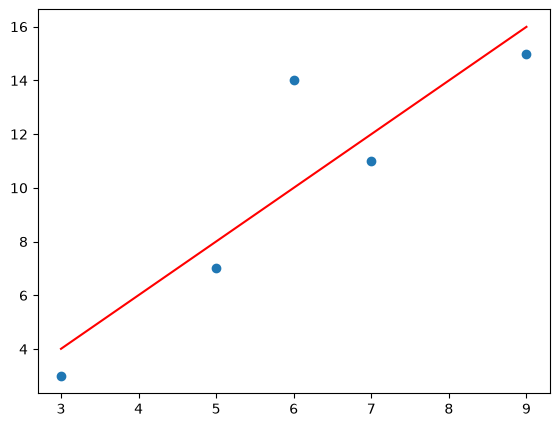

In [16]:
#Выведем график прогнозов и вычислим MSE
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

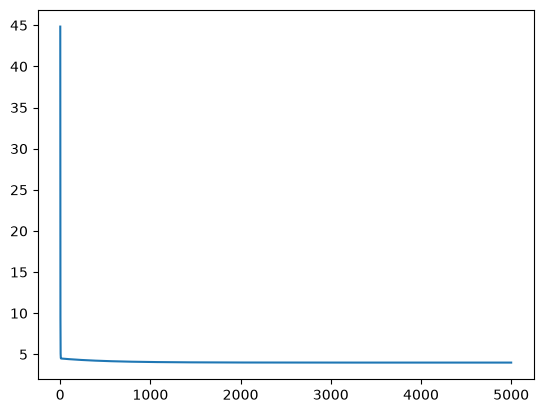

In [17]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)

MSE после градиентного спуска:  4.1903709155046345


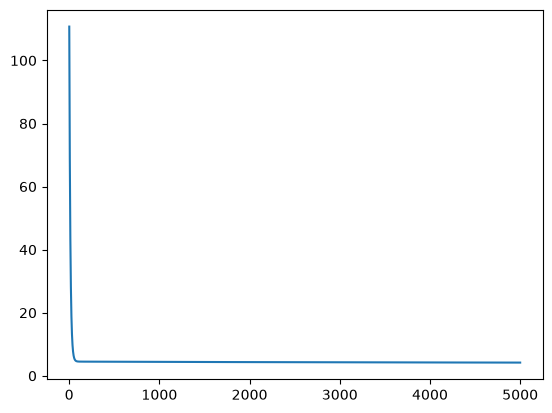

In [18]:
#Запустим цикл градиентного спуска с разными значениями скорости обучения alpha=0.0001, 0.01, 0.1, 1, 10, ..., 
#с различной допукстимой точностью epsylon = 0.001, 0.5, 5, с различным максимальным количеством шагов max_steps
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.0001, epsylon = 0.01, max_steps = 5000)
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
plt.figure()
plt.plot(steps, errors)

Загрузите файл Гиперспектр кукурузы.csv (с помощью pd.read_csv).

1. Вычислите аналитическим путем оценки коэффициентов парной линейной регрессии и постройте ее график.
2. Найдите оценки параметров модели парной лиенйной регрессии с использованием метода градиентного спуска. Постройте график.
3. Оцените качество построенных моделей сравнив на графике обучающую выборку и прогнозы.


In [19]:
gipers = pd.read_csv(r"Гиперспектр кукурузы.csv")
gipers.head()
#Y = gipers['Spectr']
#x = gipers['waveleng']

,,wavelength;Spectr
397,32;0,2.0
399,54;0,3.0
401,76;0,3.0
403,98;0,5.0
406,2;0,5.0


## Решение задания

,wavelength,Spectr
0,397.32,0.02
1,399.54,0.03
2,401.76,0.03
3,403.98,0.05
4,406.20,0.05


Точек: 273 , длина волны: от 397.32 до 1001.16 нм


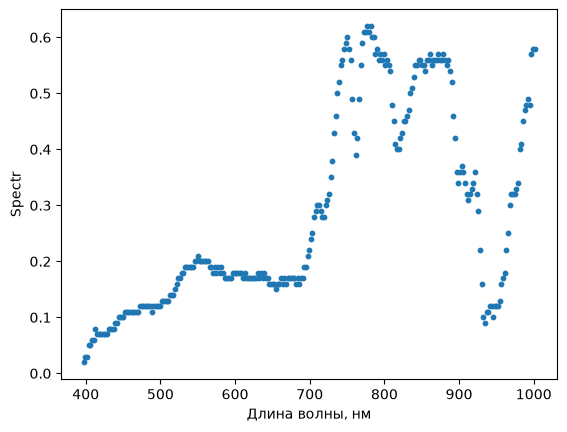

In [20]:
#Загрузим данные: разделитель столбцов ';', десятичный разделитель ','
gipers = pd.read_csv(r"Гиперспектр кукурузы.csv", sep=";", decimal=",")
display(gipers.head())
x = gipers["wavelength"].to_numpy(float)  # длина волны, нм
Y = gipers["Spectr"].to_numpy(float)      # интенсивность спектра
print("Точек:", len(x), ", длина волны: от", x.min(), "до", x.max(), "нм")

#Изобразим обучающую выборку на графике
plt.figure()
plt.scatter(x, Y, s=10)
plt.xlabel("Длина волны, нм")
plt.ylabel("Spectr")
plt.show()

### 1. Оценки коэффициентов аналитическим путём

Используем формулы метода наименьших квадратов, как в примере выше.

Модель линейной регрессии: Y^ = -0.1834278267811973  + 0.0006681550262486285 * x


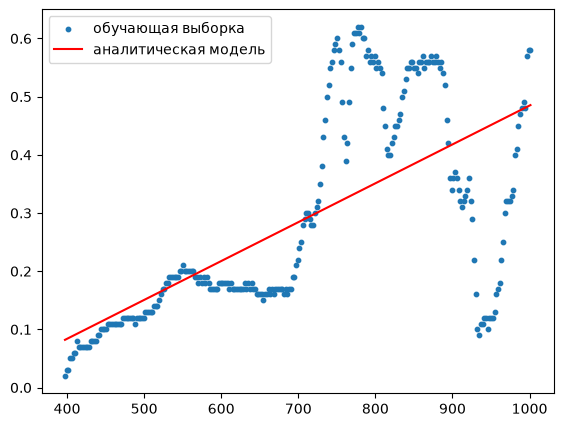

In [21]:
#Вычислим оценки коэффициентов парной линейной регрессии по формулам
a1 = ((x - x.mean())*(Y - Y.mean())).mean()/((x - x.mean())**2).mean()
a0 = Y.mean() - a1*x.mean()
print("Модель линейной регрессии: Y^ =", a0, " +", a1, "* x")

#Изобразим на графике обучающую выборку и аналитическую модель
x_space = np.linspace(x.min(), x.max(), 100)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y, s=10, label="обучающая выборка")
ax.plot(x_space, a0 + a1*x_space, 'r', label="аналитическая модель")
ax.legend()
plt.show()

### 2. Оценки коэффициентов методом градиентного спуска

Значения $x$ (длина волны, $\approx 400 \ldots 1000$ нм) в тысячи раз
больше значений $Y$, поэтому задача минимизации плохо обусловлена:
шаг градиентного спуска, подходящий для $a_1$, «разрушает» $a_0$,
а маленький шаг делает спуск неприемлемо медленным. Проверим это:

In [22]:
#Попробуем тот же класс SimpleRegression на исходном масштабе данных
regr_raw = SimpleRegression()
steps_raw, errors_raw = regr_raw.fit(x, Y, alpha=1e-6, epsylon=0.0177, max_steps=10)
print("MSE по шагам:", errors_raw)  # MSE растёт взрывным образом

MSE по шагам: [np.float64(7367.886965014927), np.float64(588718952.8657403), np.float64(47040750244878.35), np.float64(3.758724214505773e+18), np.float64(3.0033551010913668e+23), np.float64(2.3997881590888675e+28), np.float64(1.9175165821751857e+33), np.float64(1.5321643408361557e+38), np.float64(1.2242541155325548e+43), np.float64(9.782228312273948e+47)]


Стандартный приём в такой ситуации — **стандартизация признака**:
$z = \dfrac{x - \bar x}{\sigma_x}$. Линейная модель от этого не меняется
($Y = c_0 + c_1 z$ — тот же семейство прямых), но градиентный спуск
сходится. После обучения коэффициенты переводим обратно в исходный
масштаб: $a_1 = \dfrac{c_1}{\sigma_x}$, $a_0 = c_0 - \dfrac{c_1 \bar x}{\sigma_x}$.

MSE после градиентного спуска:  0.01769133705118714
Модель линейной регрессии: Y^ = -0.18182162413230574  + 0.0006623042652607066 * x


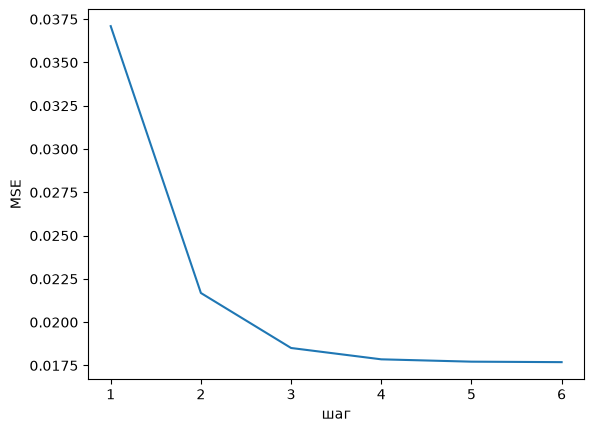

In [23]:
#Стандартизуем x и запустим градиентный спуск (тот же alpha, что в примере выше)
mu, sd = x.mean(), x.std()
z = (x - mu)/sd
regr = SimpleRegression()
steps, errors = regr.fit(z, Y, alpha=0.001, epsylon=0.0177)
print("MSE после градиентного спуска: ", regr.MSE(z, Y))

#Переводим коэффициенты в исходный масштаб: Y = c0 + c1*z = a0 + a1*x
a0_gd = regr.a0 - regr.a1*mu/sd
a1_gd = regr.a1/sd
print("Модель линейной регрессии: Y^ =", a0_gd, " +", a1_gd, "* x")

#Кривая обучения — изменение MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)
plt.xlabel("шаг")
plt.ylabel("MSE")
plt.show()

### 3. Оценка качества моделей

Сравним обучающую выборку с прогнозами обеих моделей на одном графике
и вычислим метрики ошибок MSE, MAE и MAPE.

аналитическая модель: MSE = 0.017684114628301398  MAE = 0.0968344370242086  MAPE = 0.4337699901843823
градиентный спуск:    MSE = 0.017691337051187136  MAE = 0.09660913754635458  MAPE = 0.4280632722274944


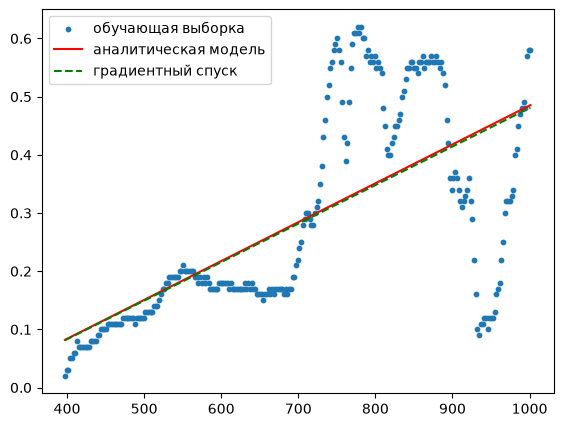

In [24]:
#Прогнозы обеих моделей на обучающей выборке
Y_pred_an = a0 + a1*x
Y_pred_gd = a0_gd + a1_gd*x

print("аналитическая модель: MSE =", ((Y - Y_pred_an)**2).mean(),
      " MAE =", abs(Y - Y_pred_an).mean(),
      " MAPE =", (abs((Y - Y_pred_an)/Y)).mean())
print("градиентный спуск:    MSE =", ((Y - Y_pred_gd)**2).mean(),
      " MAE =", abs(Y - Y_pred_gd).mean(),
      " MAPE =", (abs((Y - Y_pred_gd)/Y)).mean())

#Сравним на графике обучающую выборку и прогнозы обеих моделей
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y, s=10, label="обучающая выборка")
ax.plot(x_space, a0 + a1*x_space, 'r', label="аналитическая модель")
ax.plot(x_space, a0_gd + a1_gd*x_space, 'g--', label="градиентный спуск")
ax.legend()
plt.show()

**Вывод.** Оценки коэффициентов, полученные аналитически
($a_0 \approx -0{,}1834$, $a_1 \approx 6{,}68 \cdot 10^{-4}$) и методом
градиентного спуска после стандартизации признака, практически совпадают,
прямые на графике неотличимы (MSE $\approx 0{,}0177$).

Качество прямолинейной модели для этих данных невысокое: зависимость
Spectr от длины волны существенно нелинейна, поэтому ошибки прогноза
велики (MAE $\approx 0{,}10$ при диапазоне $Y$ от $0{,}02$ до $0{,}62$).
MAPE получается особенно большим, так как в области малых значений $Y$
(короткие волны) относительная ошибка неконтролируемо растёт.